CELL 1 — PDF LOADER

In [2]:
from pypdf import PdfReader

def load_pdf(file_path):
    reader = PdfReader(file_path)
    documents = []

    for i, page in enumerate(reader.pages):
        text = page.extract_text()

        if text:
            documents.append({
                "content": text,
                "page": i + 1
            })

    return documents

CELL 2 — CHUNKING

In [3]:
from nltk.tokenize import sent_tokenize

def chunk_documents(documents, chunk_size=900, overlap=150):
    chunks = []

    for doc in documents:
        sentences = sent_tokenize(doc["content"])
        page = doc["page"]

        current = ""

        for sent in sentences:
            if len(current) + len(sent) < chunk_size:
                current += " " + sent
            else:
                chunks.append({
                    "content": current.strip(),
                    "page": page
                })
                current = current[-overlap:] + " " + sent

        if current:
            chunks.append({
                "content": current.strip(),
                "page": page
            })

    return chunks

CELL 3 — BGE EMBEDDING + VECTOR STORE

In [4]:
from sentence_transformers import SentenceTransformer
import faiss
import pickle
import os

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

embedding_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

def create_vector_store(chunks):
    texts = [c["content"] for c in chunks]

    embeddings = embedding_model.encode(
        texts,
        batch_size=32,
        normalize_embeddings=True,
        show_progress_bar=True
    ).astype("float32")

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    os.makedirs("vectorstore", exist_ok=True)
    faiss.write_index(index, "vectorstore/faiss.index")

    with open("vectorstore/chunks.pkl", "wb") as f:
        pickle.dump(chunks, f)

d:\pdf_rag_chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 391.72it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CELL 4 — LOAD + RETRIEVE (BGE)

In [5]:
import faiss
import pickle
import os
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

index = None
chunks = None

def load_vectorstore():
    global index, chunks

    if index is None:
        index = faiss.read_index("vectorstore/faiss.index")

    if chunks is None:
        with open("vectorstore/chunks.pkl", "rb") as f:
            chunks = pickle.load(f)

def retrieve(query, k=5):
    if not os.path.exists("vectorstore/faiss.index"):
        return []

    load_vectorstore()

    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    ).astype("float32")

    scores, indices = index.search(query_embedding, 15)

    results = []
    seen_pages = set()

    for idx in indices[0]:
        if idx == -1:
            continue

        page = chunks[idx]["page"]

        if page not in seen_pages:
            results.append(chunks[idx])
            seen_pages.add(page)

        if len(results) >= k:
            break

    return results

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 734.64it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CELL 5 — LLM (FLAN-T5 BASE)

In [6]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
llm_model = AutoModelForSeq2SeqLM.from_pretrained(model_name, local_files_only=True)

llm_model.eval()


def build_context(retrieved_docs, max_tokens=450):
    context = ""
    current_tokens = 0

    for doc in retrieved_docs:
        piece = f"[Page {doc['page']}]\n{doc['content']}\n\n"
        tokens = len(tokenizer(piece)["input_ids"])

        if current_tokens + tokens > max_tokens:
            break

        context += piece
        current_tokens += tokens

    return context


def generate_answer(query, retrieved_docs):
    if not retrieved_docs:
        return "No relevant context found."

    context = build_context(retrieved_docs)

    prompt = f"""
You are an academic PDF assistant.

STRICT RULES:
1. Answer ONLY from context
2. If unsure → say "Not found in document"
3. Use bullet points
4. Mention page number

Context:
{context}

Question: {query}
Answer:
"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.0,
            do_sample=False
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


def generate_without_rag(query):
    prompt = f"Question: {query}\nAnswer:"

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = llm_model.generate(**inputs, max_new_tokens=200)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 698.03it/s, Materializing param=shared.weight]                                                       
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


CELL 6 — BUILD VECTORSTORE

In [7]:
pdf_path = "D:/pdf_rag_chatbot/uploads/Computer_Nerworks.pdf"

docs = load_pdf(pdf_path)
chunks = chunk_documents(docs)

create_vector_store(chunks)

print("Vector store created successfully!")

Batches: 100%|██████████| 23/23 [01:38<00:00,  4.30s/it]

Vector store created successfully!


CELL 7 — TEST DATA

In [8]:
import random
import re

def generate_test_data(chunks, num_questions=10):

    test_data = []

    for chunk in random.sample(chunks, min(num_questions, len(chunks))):

        text = chunk["content"]

        # Split into sentences
        sentences = re.split(r'[.?!]', text)

        for sent in sentences:
            sent = sent.strip()

            # Skip short sentences
            if len(sent) < 40:
                continue

            # -------------------------------
            # Create Question
            # -------------------------------
            # Simple heuristic: replace first word
            words = sent.split()

            if len(words) < 6:
                continue

            question = "What is " + " ".join(words[:6]) + "?"

            # -------------------------------
            # Extract keywords
            # -------------------------------
            keywords = [
                w.lower() for w in words
                if len(w) > 3 and w.isalpha()
            ]

            # take top 5 keywords
            keywords = keywords[:5]

            if keywords:
                test_data.append({
                    "question": question,
                    "expected_keywords": keywords
                })

            break  # one QA per chunk

    return test_data

In [9]:
test_data = [
    {
        "question": "What is artificial intelligence?",
        "expected_keywords": ["simulate", "natural intelligence", "human beings", "machines"]
    },
    {
        "question": "What is Big data?",
        "expected_keywords": ["enormous volume", "complexity"]
    },
    {
        "question": "What is a tuple?",
        "expected_keywords": ["ordered sequence", "elements"]
    },
    {
        "question": "What is traversing a list?",
        "expected_keywords": ["access each element", "for loop"]
    }
]

CELL 8 — ANSWER EVALUATION

In [10]:
def evaluate_answers():
    correct = 0

    for item in test_data:
        docs = retrieve(item["question"])
        answer = generate_answer(item["question"], docs).lower()

        match = sum(kw in answer for kw in item["expected_keywords"])
        score = match / len(item["expected_keywords"])

        if score >= 0.5:
            correct += 1

        print(f"\nQ: {item['question']}")
        print(f"Answer: {answer}")
        print(f"Score: {score:.2f}")

    print(f"\nAccuracy: {correct/len(test_data):.2f}")

CELL 9 — SEMANTIC EVALUATION

In [11]:
from sentence_transformers import util

def evaluate_semantic():
    for item in test_data:
        docs = retrieve(item["question"])
        answer = generate_answer(item["question"], docs)

        score = util.cos_sim(
            embedding_model.encode(answer, convert_to_tensor=True),
            embedding_model.encode(" ".join(item["expected_keywords"]), convert_to_tensor=True)
        ).item()

        print(f"{item['question']} -> {score:.2f}")

CELL 10 — RETRIEVAL QUALITY

In [12]:
def evaluate_retrieval_quality():
    for item in test_data:
        docs = retrieve(item["question"])
        combined = " ".join([d["content"] for d in docs]).lower()

        match = any(kw in combined for kw in item["expected_keywords"])
        print(f"{item['question']} -> {'Relevant' if match else 'Not Relevant'}")

CELL 11 — PERFORMANCE

In [13]:
import time

def evaluate_performance():
    times = []

    for item in test_data:
        start = time.time()
        docs = retrieve(item["question"])
        generate_answer(item["question"], docs)
        times.append(time.time() - start)

    print(f"Avg Time: {sum(times)/len(times):.2f} sec")

## COMPARISON SECTION

CELL 13 — MiniLM MODEL

In [14]:
from sentence_transformers import SentenceTransformer

embedding_model_mini = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 197.74it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CELL 14 — MiniLM VECTOR STORE

In [15]:
import faiss
import pickle
import os

def create_vector_store_mini(chunks):
    texts = [c["content"] for c in chunks]

    embeddings = embedding_model_mini.encode(
        texts,
        batch_size=32,
        normalize_embeddings=True
    ).astype("float32")

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    os.makedirs("vectorstore_mini", exist_ok=True)

    faiss.write_index(index, "vectorstore_mini/faiss.index")

    with open("vectorstore_mini/chunks.pkl", "wb") as f:
        pickle.dump(chunks, f)

    print("MiniLM vector store created")

CELL 15 — RETRIEVE MiniLM

In [16]:
def retrieve_mini(query, k=5):

    if not os.path.exists("vectorstore_mini/faiss.index"):
        return []

    index = faiss.read_index("vectorstore_mini/faiss.index")

    with open("vectorstore_mini/chunks.pkl", "rb") as f:
        chunks = pickle.load(f)

    query_embedding = embedding_model_mini.encode(
        [query],
        normalize_embeddings=True
    ).astype("float32")

    scores, indices = index.search(query_embedding, k)

    return [chunks[i] for i in indices[0] if i != -1]

CELL 16 — BGE vs MiniLM

In [17]:
def compare_embedding_models():

    for item in test_data:
        query = item["question"]

        docs_bge = retrieve(query)
        docs_mini = retrieve_mini(query)

        text_bge = " ".join([d["content"] for d in docs_bge]).lower()
        text_mini = " ".join([d["content"] for d in docs_mini]).lower()

        keywords = item["expected_keywords"]

        score_bge = sum(kw in text_bge for kw in keywords)
        score_mini = sum(kw in text_mini for kw in keywords)

        print(f"\nQ: {query}")
        print(f"BGE Score: {score_bge}")
        print(f"MiniLM Score: {score_mini}")

CELL 17 — SMALL LLM

In [18]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name_small = "google/flan-t5-small"

tokenizer_small = AutoTokenizer.from_pretrained(model_name_small, local_files_only=True)
llm_model_small = AutoModelForSeq2SeqLM.from_pretrained(model_name_small, local_files_only=True)

llm_model_small.eval()

Loading weights: 100%|██████████| 190/190 [00:01<00:00, 144.87it/s, Materializing param=shared.weight]                                                       
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
              (wo): 

CELL 18 — GENERATE SMALL

In [19]:
def generate_answer_small(query, retrieved_docs):

    if not retrieved_docs:
        return "No relevant context found."

    context = build_context(retrieved_docs)

    prompt = f"""
Answer using context:

{context}

Question: {query}
Answer:
"""

    inputs = tokenizer_small(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = llm_model_small.generate(
            **inputs,
            max_new_tokens=200
        )

    return tokenizer_small.decode(outputs[0], skip_special_tokens=True)

CELL 19 — LLM COMPARISON

In [20]:
from sentence_transformers import util

def compare_llms():

    for item in test_data:
        query = item["question"]
        expected = " ".join(item["expected_keywords"])

        docs = retrieve(query)

        ans_base = generate_answer(query, docs)
        ans_small = generate_answer_small(query, docs)

        emb_expected = embedding_model.encode(expected, convert_to_tensor=True)

        score_base = util.cos_sim(
            embedding_model.encode(ans_base, convert_to_tensor=True),
            emb_expected
        ).item()

        score_small = util.cos_sim(
            embedding_model.encode(ans_small, convert_to_tensor=True),
            emb_expected
        ).item()

        print(f"\nQ: {query}")
        print(f"T5-base: {score_base:.2f}")
        print(f"T5-small: {score_small:.2f}")

In [21]:
create_vector_store_mini(chunks)

MiniLM vector store created


SMART TEST GENERATION (USING YOUR EXISTING LLM)

In [22]:
def generate_test_data_llm(chunks, num_questions=10):

    test_data = []

    sampled_chunks = chunks[:num_questions]

    for chunk in sampled_chunks:

        context = chunk["content"][:500]  # keep it short

        prompt = f"""
Generate ONE question and 5 keywords from the context.

Rules:
- Question must test understanding
- Keywords must be important terms from context
- Output format strictly:

Question: ...
Keywords: word1, word2, word3, word4, word5

Context:
{context}
"""

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        with torch.no_grad():
            outputs = llm_model.generate(
                **inputs,
                max_new_tokens=100,
                temperature=0.3
            )

        text = tokenizer.decode(outputs[0], skip_special_tokens=True)

        try:
            q_part = text.split("Question:")[1].split("Keywords:")[0].strip()
            k_part = text.split("Keywords:")[1].strip()

            keywords = [k.strip().lower() for k in k_part.split(",")]

            if len(keywords) >= 3:
                test_data.append({
                    "question": q_part,
                    "expected_keywords": keywords[:5]
                })

        except:
            continue

    return test_data

In [23]:
llm_test_data = generate_test_data_llm(chunks, 10)

# Combine with your original
test_data = test_data + llm_test_data

print(test_data[:5])

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[{'question': 'What is artificial intelligence?', 'expected_keywords': ['simulate', 'natural intelligence', 'human beings', 'machines']}, {'question': 'What is Big data?', 'expected_keywords': ['enormous volume', 'complexity']}, {'question': 'What is a tuple?', 'expected_keywords': ['ordered sequence', 'elements']}, {'question': 'What is traversing a list?', 'expected_keywords': ['access each element', 'for loop']}]


In [24]:
semantic_test_data = [

    # {
    #     "question": "How do machines imitate human thinking abilities?",
    #     "expected_keywords": ["simulate", "human intelligence", "machines"]
    # },

    {
        "question": "What defines datasets that are too large and complex to process traditionally?",
        "expected_keywords": ["big data", "volume", "complexity"]
    },

    {
        "question": "Explain a data structure that keeps elements in a fixed order but allows different types.",
        "expected_keywords": ["tuple", "ordered sequence", "different data types"]
    },

    {
        "question": "How can we iterate through every element in a collection sequentially?",
        "expected_keywords": ["traverse", "loop", "access element"]
    },

    # {
    #     "question": "What concept allows computers to perform tasks requiring human-like decision making?",
    #     "expected_keywords": ["artificial intelligence", "machines", "intelligence"]
    # }
]

In [25]:
test_data = test_data + semantic_test_data + llm_test_data

## EVALUATION

In [26]:
import time
from sentence_transformers import util

print("\n" + "="*65)
print("COMPLETE RAG MODEL COMPARISON REPORT")
print("="*65)

# -------------------------------
# 1. EMBEDDING COMPARISON
# -------------------------------
print("\n1. EMBEDDING MODELS: BGE vs MiniLM")
print("Metrics: Keyword Coverage | Semantic Similarity | Retrieval Time\n")

embed_results = []

for item in test_data:
    query = item["question"]
    expected = " ".join(item["expected_keywords"])

    # BGE
    start = time.time()
    docs_bge = retrieve(query)
    time_bge = time.time() - start
    text_bge = " ".join([d["content"] for d in docs_bge]).lower()

    kw_bge = sum(kw in text_bge for kw in item["expected_keywords"])
    sem_bge = util.cos_sim(
        embedding_model.encode(text_bge, convert_to_tensor=True),
        embedding_model.encode(expected, convert_to_tensor=True)
    ).item()

    # MiniLM
    start = time.time()
    docs_mini = retrieve_mini(query)
    time_mini = time.time() - start
    text_mini = " ".join([d["content"] for d in docs_mini]).lower()

    kw_mini = sum(kw in text_mini for kw in item["expected_keywords"])
    sem_mini = util.cos_sim(
        embedding_model_mini.encode(text_mini, convert_to_tensor=True),
        embedding_model_mini.encode(expected, convert_to_tensor=True)
    ).item()

    print(f"\nQ: {query}")
    print(f"BGE     → KW: {kw_bge} | Sem: {sem_bge:.2f} | Time: {time_bge:.3f}s")
    print(f"MiniLM  → KW: {kw_mini} | Sem: {sem_mini:.2f} | Time: {time_mini:.3f}s")

    embed_results.append((kw_bge, sem_bge, time_bge, kw_mini, sem_mini, time_mini))


COMPLETE RAG MODEL COMPARISON REPORT

1. EMBEDDING MODELS: BGE vs MiniLM
Metrics: Keyword Coverage | Semantic Similarity | Retrieval Time


Q: What is artificial intelligence?
BGE     → KW: 4 | Sem: 0.79 | Time: 0.072s
MiniLM  → KW: 4 | Sem: 0.54 | Time: 0.078s

Q: What is Big data?
BGE     → KW: 2 | Sem: 0.62 | Time: 0.039s
MiniLM  → KW: 2 | Sem: 0.27 | Time: 0.029s

Q: What is a tuple?
BGE     → KW: 2 | Sem: 0.70 | Time: 0.040s
MiniLM  → KW: 2 | Sem: 0.33 | Time: 0.028s

Q: What is traversing a list?
BGE     → KW: 2 | Sem: 0.67 | Time: 0.038s
MiniLM  → KW: 2 | Sem: 0.35 | Time: 0.027s

Q: What defines datasets that are too large and complex to process traditionally?
BGE     → KW: 3 | Sem: 0.75 | Time: 0.050s
MiniLM  → KW: 3 | Sem: 0.55 | Time: 0.034s

Q: Explain a data structure that keeps elements in a fixed order but allows different types.
BGE     → KW: 3 | Sem: 0.81 | Time: 0.045s
MiniLM  → KW: 3 | Sem: 0.51 | Time: 0.033s

Q: How can we iterate through every element in a collec

In [27]:

# -------------------------------
# 2. LLM COMPARISON
# -------------------------------
print("\n 2. LLM MODELS: FLAN-T5 Base vs Small")
print("Metrics: Semantic Similarity | Generation Time\n")

llm_results = []

for item in test_data:
    query = item["question"]
    expected = " ".join(item["expected_keywords"])
    docs = retrieve(query)

    # Base
    start = time.time()
    ans_base = generate_answer(query, docs)
    time_base = time.time() - start

    # Small
    start = time.time()
    ans_small = generate_answer_small(query, docs)
    time_small = time.time() - start

    emb_expected = embedding_model.encode(expected, convert_to_tensor=True)

    score_base = util.cos_sim(
        embedding_model.encode(ans_base, convert_to_tensor=True),
        emb_expected
    ).item()

    score_small = util.cos_sim(
        embedding_model.encode(ans_small, convert_to_tensor=True),
        emb_expected
    ).item()

    print(f"\nQ: {query}")
    print(f"T5-base  → Score: {score_base:.2f} | Time: {time_base:.3f}s")
    print(f"T5-small → Score: {score_small:.2f} | Time: {time_small:.3f}s")

    llm_results.append((score_base, time_base, score_small, time_small))


 2. LLM MODELS: FLAN-T5 Base vs Small
Metrics: Semantic Similarity | Generation Time


Q: What is artificial intelligence?
T5-base  → Score: 0.90 | Time: 2.784s
T5-small → Score: 0.68 | Time: 1.246s

Q: What is Big data?
T5-base  → Score: 0.87 | Time: 1.659s
T5-small → Score: 0.66 | Time: 0.492s

Q: What is a tuple?
T5-base  → Score: 0.91 | Time: 2.249s
T5-small → Score: 0.91 | Time: 1.040s

Q: What is traversing a list?
T5-base  → Score: 0.86 | Time: 2.916s
T5-small → Score: 0.64 | Time: 0.703s

Q: What defines datasets that are too large and complex to process traditionally?
T5-base  → Score: 0.82 | Time: 1.600s
T5-small → Score: 0.67 | Time: 0.524s

Q: Explain a data structure that keeps elements in a fixed order but allows different types.
T5-base  → Score: 0.65 | Time: 1.035s
T5-small → Score: 0.59 | Time: 9.107s

Q: How can we iterate through every element in a collection sequentially?
T5-base  → Score: 0.69 | Time: 21.218s
T5-small → Score: 0.58 | Time: 2.098s


SIDE-BY-SIDE ANSWER COMPARISON

In [28]:
def compare_answers():

    print("\n" + "="*65)
    print("ANSWER COMPARISON (RAG SYSTEMS)")
    print("BGE + T5-base  vs  MiniLM + T5-small")
    print("="*65)

    for item in test_data:
        query = item["question"]

        print("\n" + "-"*60)
        print(f"Q: {query}")
        print("-"*60)

        # ---------------- BGE + T5-base ----------------
        docs_bge = retrieve(query)
        ans_bge = generate_answer(query, docs_bge)

        # ---------------- MiniLM + T5-small ----------------
        docs_mini = retrieve_mini(query)
        ans_mini = generate_answer_small(query, docs_mini)

        # ---------------- PRINT ----------------
        print("\nBGE + FLAN-T5 Base Answer:")
        print(ans_bge)

        print("\nMiniLM + FLAN-T5 Small Answer:")
        print(ans_mini)

compare_answers()


ANSWER COMPARISON (RAG SYSTEMS)
BGE + T5-base  vs  MiniLM + T5-small

------------------------------------------------------------
Q: What is artificial intelligence?
------------------------------------------------------------

BGE + FLAN-T5 Base Answer:
endeavours to simulate the natural intelligence of human beings into machines, thus making them behave intelligently

MiniLM + FLAN-T5 Small Answer:
Machine Learning Machine Learning

------------------------------------------------------------
Q: What is Big data?
------------------------------------------------------------

BGE + FLAN-T5 Base Answer:
data sets of enormous volume and complexity

MiniLM + FLAN-T5 Small Answer:
Big data

------------------------------------------------------------
Q: What is a tuple?
------------------------------------------------------------

BGE + FLAN-T5 Base Answer:
an ordered sequence of elements of different data types

MiniLM + FLAN-T5 Small Answer:
an ordered sequence of elements of different

In [29]:

# -------------------------------
# 3. END-TO-END SYSTEM COMPARISON
# -------------------------------
print("\n 3. FULL SYSTEM COMPARISON")
print("BGE + T5-base  vs  MiniLM + T5-small")
print("Metrics: Semantic Similarity | Total Response Time\n")

system_results = []

for item in test_data:
    query = item["question"]
    expected = " ".join(item["expected_keywords"])

    # System 1: BGE + Base
    start = time.time()
    docs_bge = retrieve(query)
    ans_bge = generate_answer(query, docs_bge)
    time_bge_sys = time.time() - start

    # System 2: MiniLM + Small
    start = time.time()
    docs_mini = retrieve_mini(query)
    ans_mini = generate_answer_small(query, docs_mini)
    time_mini_sys = time.time() - start

    emb_expected = embedding_model.encode(expected, convert_to_tensor=True)

    score_bge_sys = util.cos_sim(
        embedding_model.encode(ans_bge, convert_to_tensor=True),
        emb_expected
    ).item()

    score_mini_sys = util.cos_sim(
        embedding_model.encode(ans_mini, convert_to_tensor=True),
        emb_expected
    ).item()

    print(f"\nQ: {query}")
    print(f"BGE+Base   → Score: {score_bge_sys:.2f} | Time: {time_bge_sys:.3f}s")
    print(f"Mini+Small → Score: {score_mini_sys:.2f} | Time: {time_mini_sys:.3f}s")

    system_results.append((score_bge_sys, time_bge_sys, score_mini_sys, time_mini_sys))


 3. FULL SYSTEM COMPARISON
BGE + T5-base  vs  MiniLM + T5-small
Metrics: Semantic Similarity | Total Response Time


Q: What is artificial intelligence?
BGE+Base   → Score: 0.90 | Time: 3.176s
Mini+Small → Score: 0.68 | Time: 1.263s

Q: What is Big data?
BGE+Base   → Score: 0.87 | Time: 3.632s
Mini+Small → Score: 0.66 | Time: 0.471s

Q: What is a tuple?
BGE+Base   → Score: 0.91 | Time: 2.026s
Mini+Small → Score: 0.91 | Time: 0.642s

Q: What is traversing a list?
BGE+Base   → Score: 0.86 | Time: 3.004s
Mini+Small → Score: 0.64 | Time: 0.524s

Q: What defines datasets that are too large and complex to process traditionally?
BGE+Base   → Score: 0.82 | Time: 1.478s
Mini+Small → Score: 0.64 | Time: 0.543s

Q: Explain a data structure that keeps elements in a fixed order but allows different types.
BGE+Base   → Score: 0.65 | Time: 1.646s
Mini+Small → Score: 0.62 | Time: 8.299s

Q: How can we iterate through every element in a collection sequentially?
BGE+Base   → Score: 0.69 | Time: 14.087s

In [30]:
# -------------------------------
# 4. FINAL SUMMARY TABLE
# -------------------------------
print("\n" + "="*65)
print("FINAL SUMMARY")
print("="*65)

# Embedding avg
avg_bge_sem = sum(r[1] for r in embed_results)/len(embed_results)
avg_mini_sem = sum(r[4] for r in embed_results)/len(embed_results)

# LLM avg
avg_base = sum(r[0] for r in llm_results)/len(llm_results)
avg_small = sum(r[2] for r in llm_results)/len(llm_results)

# System avg
avg_sys_bge = sum(r[0] for r in system_results)/len(system_results)
avg_sys_mini = sum(r[2] for r in system_results)/len(system_results)

print("\nEMBEDDINGS:")
print(f"BGE Avg Semantic: {avg_bge_sem:.2f}")
print(f"MiniLM Avg Semantic: {avg_mini_sem:.2f}")

print("\nLLMs:")
print(f"T5-base Avg Score: {avg_base:.2f}")
print(f"T5-small Avg Score: {avg_small:.2f}")

print("\nFULL SYSTEM:")
print(f"BGE + T5-base Avg Score: {avg_sys_bge:.2f}")
print(f"MiniLM + T5-small Avg Score: {avg_sys_mini:.2f}")

print("\nFINAL CONCLUSION:")
print(" Best Embedding → BGE")
print(" Best LLM → FLAN-T5 Base")
print(" Best Overall System → BGE + FLAN-T5 Base")


FINAL SUMMARY

EMBEDDINGS:
BGE Avg Semantic: 0.72
MiniLM Avg Semantic: 0.44

LLMs:
T5-base Avg Score: 0.81
T5-small Avg Score: 0.67

FULL SYSTEM:
BGE + T5-base Avg Score: 0.81
MiniLM + T5-small Avg Score: 0.69

FINAL CONCLUSION:
 Best Embedding → BGE
 Best LLM → FLAN-T5 Base
 Best Overall System → BGE + FLAN-T5 Base


GRAPH CELL

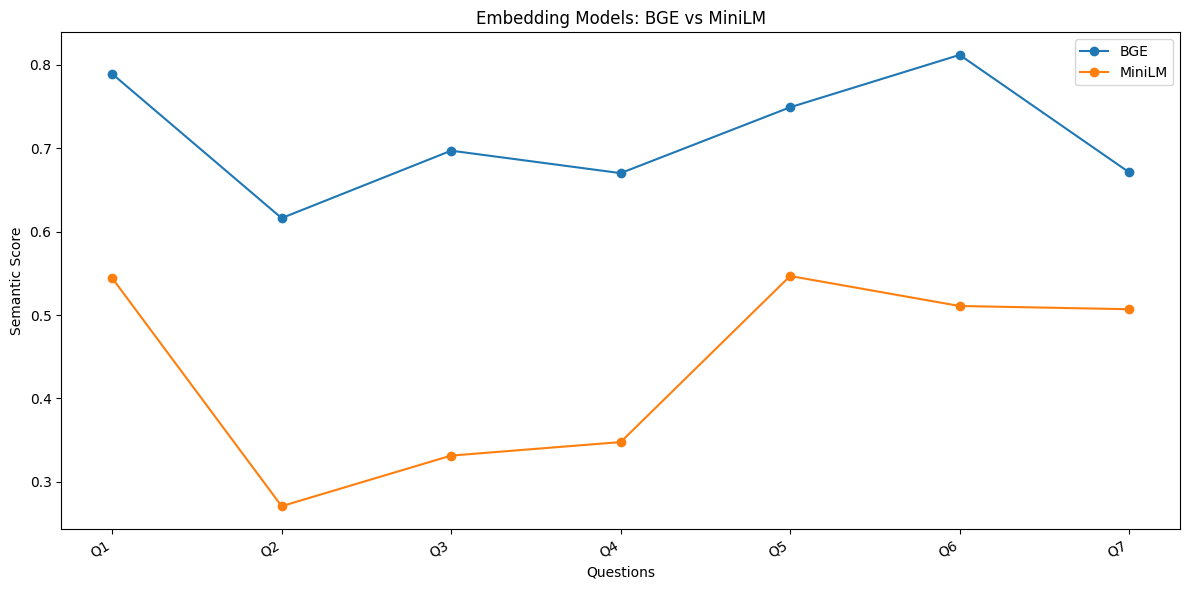

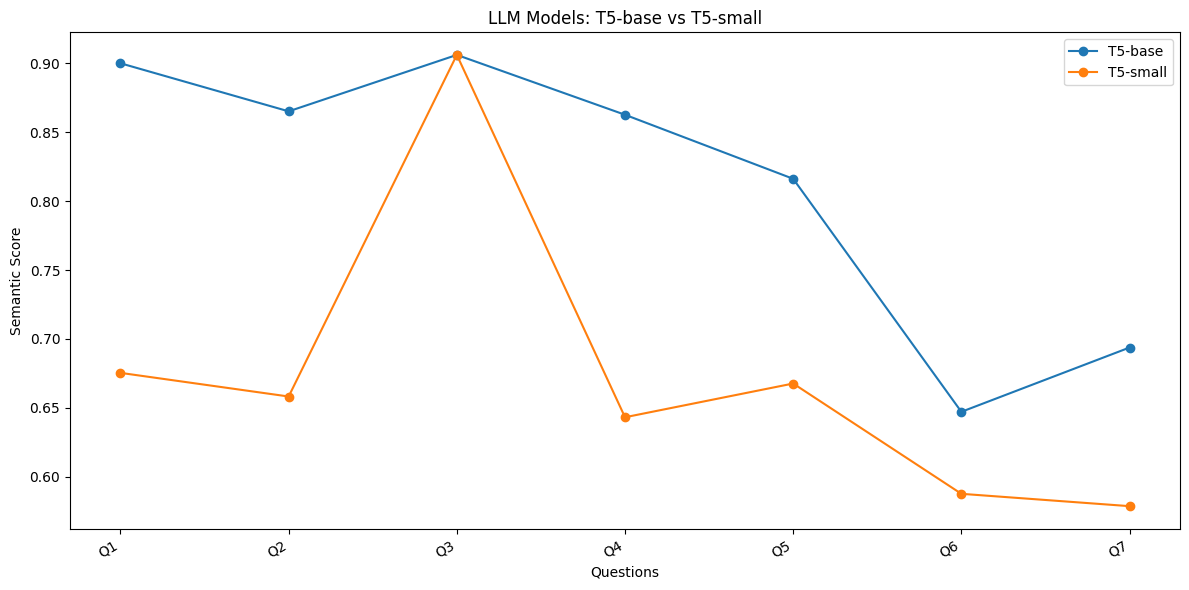

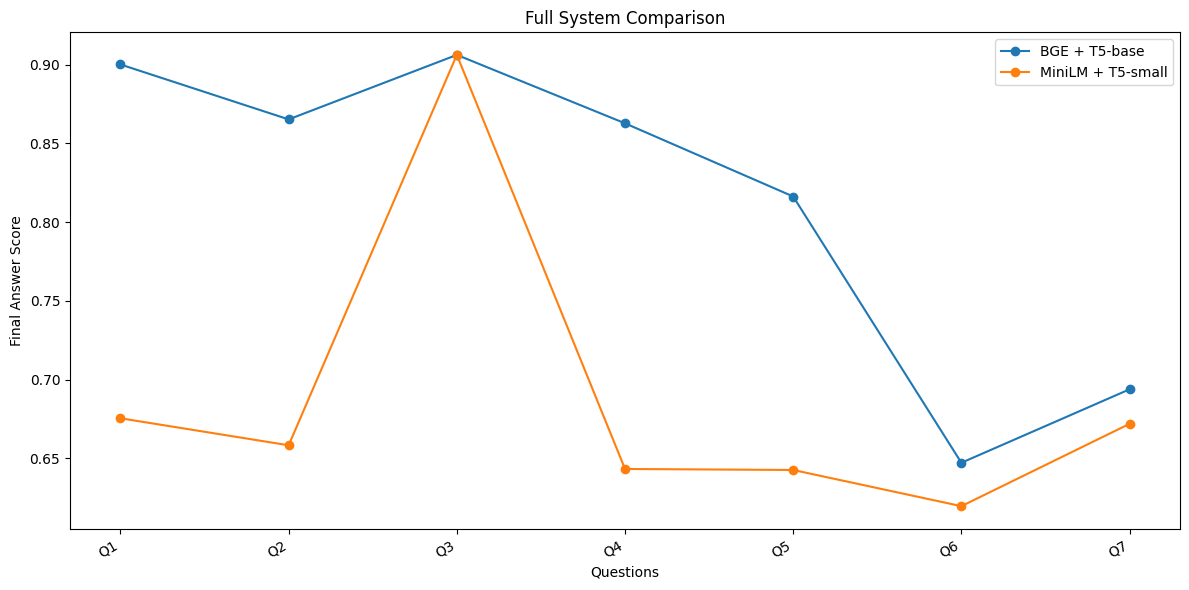


Question Mapping:
Q1: What is artificial intelligence?
Q2: What is Big data?
Q3: What is a tuple?
Q4: What is traversing a list?
Q5: What defines datasets that are too large and complex to process traditionally?
Q6: Explain a data structure that keeps elements in a fixed order but allows different types.
Q7: How can we iterate through every element in a collection sequentially?


In [31]:
import matplotlib.pyplot as plt

# Use short labels
labels = [f"Q{i+1}" for i in range(len(test_data))]

# -------------------------------
# 1. EMBEDDING COMPARISON GRAPH
# -------------------------------
bge_sem = [r[1] for r in embed_results]
mini_sem = [r[4] for r in embed_results]

plt.figure(figsize=(12, 6))
plt.plot(labels, bge_sem, marker='o', label="BGE")
plt.plot(labels, mini_sem, marker='o', label="MiniLM")

plt.xlabel("Questions")
plt.ylabel("Semantic Score")
plt.title("Embedding Models: BGE vs MiniLM")

plt.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


# -------------------------------
# 2. LLM COMPARISON GRAPH
# -------------------------------
base_scores = [r[0] for r in llm_results]
small_scores = [r[2] for r in llm_results]

plt.figure(figsize=(12, 6))
plt.plot(labels, base_scores, marker='o', label="T5-base")
plt.plot(labels, small_scores, marker='o', label="T5-small")

plt.xlabel("Questions")
plt.ylabel("Semantic Score")
plt.title("LLM Models: T5-base vs T5-small")

plt.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


# -------------------------------
# 3. FULL SYSTEM COMPARISON GRAPH
# -------------------------------
bge_sys = [r[0] for r in system_results]
mini_sys = [r[2] for r in system_results]

plt.figure(figsize=(12, 6))
plt.plot(labels, bge_sys, marker='o', label="BGE + T5-base")
plt.plot(labels, mini_sys, marker='o', label="MiniLM + T5-small")

plt.xlabel("Questions")
plt.ylabel("Final Answer Score")
plt.title("Full System Comparison")

plt.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


# -------------------------------
# PRINT FULL QUESTIONS (REFERENCE)
# -------------------------------
print("\nQuestion Mapping:")
for i, item in enumerate(test_data):
    print(f"Q{i+1}: {item['question']}")